# FlowMatchingActionHead: does the rectified-flow denoising loop actually converge to a sensible plan?

**Background.** `models.action_head_flow.FlowMatchingActionHead` is the chunked, flow-matching alternative to the simple single-shot `ActionHead` -- groundwork for `docs/MILESTONES.md`'s prioritized experiment 4 (deliberately not yet trained at real scale or compared to the simple head, see that file). It reuses pi0.5/openpi's rectified-flow mechanism: `compute_loss` trains a velocity field `v_t` against the constant target velocity `u_t = noise - target_chunk`, and `sample` integrates that velocity field with `num_steps` Euler steps from `t=1` (pure noise) to `t=0` (data).

Unit tests (`tests/test_action_head_flow.py`) already confirm the loss shape, PFN-gradient-isolation, and that `sample` produces valid `[0,1]^x_dim` output. What they don't show is what the denoising trajectory actually *looks like* -- does each chunk-step token's `x_t` visibly move from noise toward something structured over the `num_steps` Euler iterations, or does it just jitter? This notebook trains a tiny flow head on `pfn_smoke_xdim1.pt` (x_dim=1, so every trajectory is directly plottable), then visualizes:

1. The training loss curve (real learning signal, not just "runs without erroring").
2. The Euler-integration denoising trajectory itself, `x_t` at every intermediate step for each of the `chunk_len` tokens, overlaid on the actual BNN surface and context the chunk was sampled for.
3. Where the final sampled point lands relative to the context's own incumbent, across several different contexts.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.models.action_head import pfn_dims
from anytimeacquisition.models.action_head_flow import FlowMatchingActionHead
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.trainer.action_head_flow_trainer import ActionHeadFlowTrainer
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

torch.manual_seed(0)
checkpoint_path = CHECKPOINT_DIR / "pfn_smoke_xdim1.pt"
pfn, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
x_dim = ckpt["config"]["max_x_dim"]
d_model, n_layers = pfn_dims(pfn)
print(f"loaded {checkpoint_path.name}: x_dim={x_dim}")

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded pfn_smoke_xdim1.pt: x_dim=1


## Train a small flow head (integrated: exploit + explore, k-step chunk targets via `search.kstep_explore`)

rollout     0  policy_loss/train=1.4234  n_exploit=7  n_explore=108


rollout     1  policy_loss/train=1.2285  n_exploit=11  n_explore=64


rollout     2  policy_loss/train=1.5306  n_exploit=8  n_explore=40


rollout     3  policy_loss/train=1.1990  n_exploit=9  n_explore=55


rollout     4  policy_loss/train=1.1458  n_exploit=11  n_explore=44


...

rollout    35  policy_loss/train=0.4469  n_exploit=6  n_explore=34


rollout    36  policy_loss/train=0.3893  n_exploit=11  n_explore=50


rollout    37  policy_loss/train=0.4544  n_exploit=15  n_explore=42


rollout    38  policy_loss/train=0.3664  n_exploit=19  n_explore=65


rollout    39  policy_loss/train=0.5943  n_exploit=7  n_explore=72


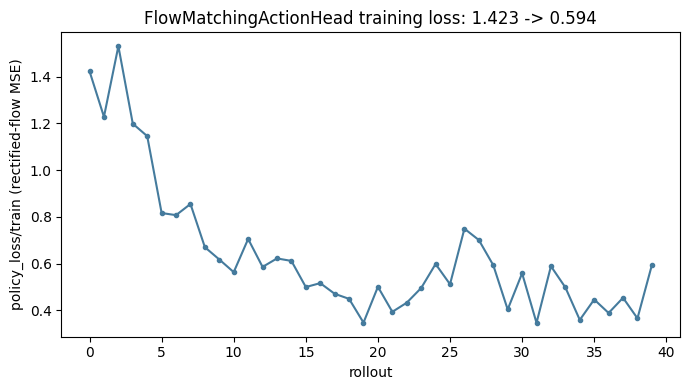

In [2]:
torch.manual_seed(2)
chunk_len = 3
prior = BNNPrior(batch_size=8, x_dim=x_dim, seed=4)
action_head = FlowMatchingActionHead(
    pfn_d_model=d_model, pfn_n_layers=n_layers, x_dim=x_dim, chunk_len=chunk_len,
    d_model=32, n_heads=2, d_ff=64,
)

trainer = ActionHeadFlowTrainer(
    pfn=pfn, bar_dist=bar_dist, prior=prior, action_head=action_head,
    n_rollouts=40, n_init=5, n_steps=15, log_every=1, chunk_len=chunk_len, num_sample_steps=10,
    exploit_search_kwargs={"n_restarts": 2, "n_steps": 10},
    explore_search_kwargs={"n_restarts": 1, "n_steps": 10},
    build_interesting_points_kwargs={"n_sobol": 8, "n_random": 8, "n_basin_restarts": 4},
)
result = trainer.run()
history = result["history"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["step"], history["policy_loss/train"], marker="o", markersize=3, color="#457b9d")
ax.set_xlabel("rollout")
ax.set_ylabel("policy_loss/train (rectified-flow MSE)")
ax.set_title(f"FlowMatchingActionHead training loss: {history['policy_loss/train'][0]:.3f} -> {history['policy_loss/train'][-1]:.3f}")
fig.tight_layout()
plt.show()

## Visualize the Euler-integration denoising trajectory

`FlowMatchingActionHead.sample` (`models/action_head_flow.py`) doesn't expose intermediate `x_t` values -- it only returns the final `x_0`. The function below is a local, trajectory-recording copy of exactly the same loop (same `hidden_states` computed once, same `dt`/`t` update, same final clamp) so every intermediate Euler step can be plotted, without changing the production sampler.

In [3]:
@torch.no_grad()
def sample_with_trajectory(action_head, pfn, x_train, y_train, aux_features, num_steps=10):
    '''Same Euler-integration loop as FlowMatchingActionHead.sample, but
    records x_t at every intermediate step for plotting -- production
    sample() only ever needs/returns the final x_0.'''
    from anytimeacquisition.models.action_head import compute_pfn_hidden_states

    B = x_train.shape[0]
    hidden_states = compute_pfn_hidden_states(pfn, x_train, y_train, blind=False)

    x_t = torch.randn(B, action_head.chunk_len, action_head.x_dim, device=x_train.device)
    dt = -1.0 / num_steps
    t = torch.ones(B, device=x_train.device)
    trajectory = [x_t.clone()]
    for _ in range(num_steps):
        v_t = action_head.forward_velocity(hidden_states, aux_features, x_t, t)
        x_t = x_t + dt * v_t
        t = t + dt
        trajectory.append(x_t.clone())
    trajectory[-1] = trajectory[-1].clamp(0.0, 1.0)
    return trajectory  # list of length num_steps+1, each [B, chunk_len, x_dim]


torch.manual_seed(7)
eval_prior = BNNPrior(batch_size=4, x_dim=x_dim, seed=11)
x_ctx, y_ctx, _, _ = eval_prior.sample_episode(n_train=8, n_test=0)
incumbent = y_ctx.min(dim=1).values
aux = {
    "step_count": torch.full((4,), 10.0),
    "remaining_budget": torch.full((4,), 0.3),
    "incumbent_value": incumbent,
    "improvement_trend": torch.zeros(4),
}
num_steps = 12
trajectory = sample_with_trajectory(action_head, pfn, x_ctx, y_ctx, aux, num_steps=num_steps)
traj = torch.stack(trajectory, dim=0)  # [num_steps+1, B, chunk_len, x_dim]
print("trajectory shape:", tuple(traj.shape), "(euler_step, instance, chunk_step, x_dim)")

trajectory shape: (13, 4, 3, 1) (euler_step, instance, chunk_step, x_dim)


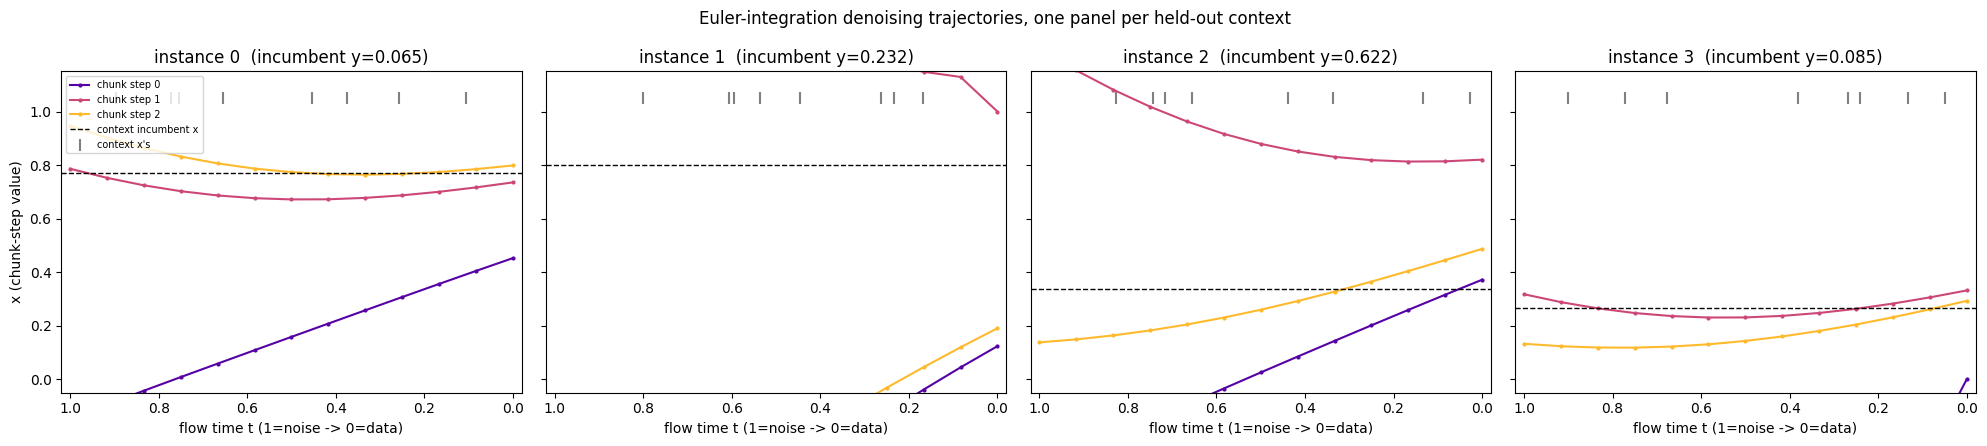

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
t_axis = np.linspace(1.0, 0.0, num_steps + 1)  # t=1 (noise) -> t=0 (data)
colors = plt.get_cmap("plasma")(np.linspace(0.15, 0.85, chunk_len))

for b, ax in enumerate(axes):
    for c in range(chunk_len):
        ax.plot(t_axis, traj[:, b, c, 0].numpy(), marker=".", markersize=4, color=colors[c],
                label=f"chunk step {c}" if b == 0 else None)
    ax.axhline(x_ctx[b, y_ctx[b].argmin()].item(), color="black", linestyle="--", linewidth=1.0,
               label="context incumbent x" if b == 0 else None)
    ax.scatter(x_ctx[b, :, 0].numpy(), [1.05] * x_ctx.shape[1], marker="|", color="gray", s=80,
               label="context x's" if b == 0 else None)
    ax.set_xlim(1.02, -0.02)  # denoising runs t: 1 -> 0, so flip the x-axis to match that direction
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel("flow time t (1=noise -> 0=data)")
    ax.set_title(f"instance {b}  (incumbent y={incumbent[b].item():.3f})")
axes[0].set_ylabel("x (chunk-step value)")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Euler-integration denoising trajectories, one panel per held-out context")
fig.tight_layout()
plt.show()

## Where does the final sampled point land, relative to the true BNN surface?

`x_dim=1`, so the whole surface is directly plottable: the true function (privileged, `noise=False`), the context points the chunk was conditioned on, and the flow head's own sampled chunk (only `chunk[:, 0]` is ever meant to be deployed -- the rest is planning leverage, same discipline as `search.kstep_explore`).

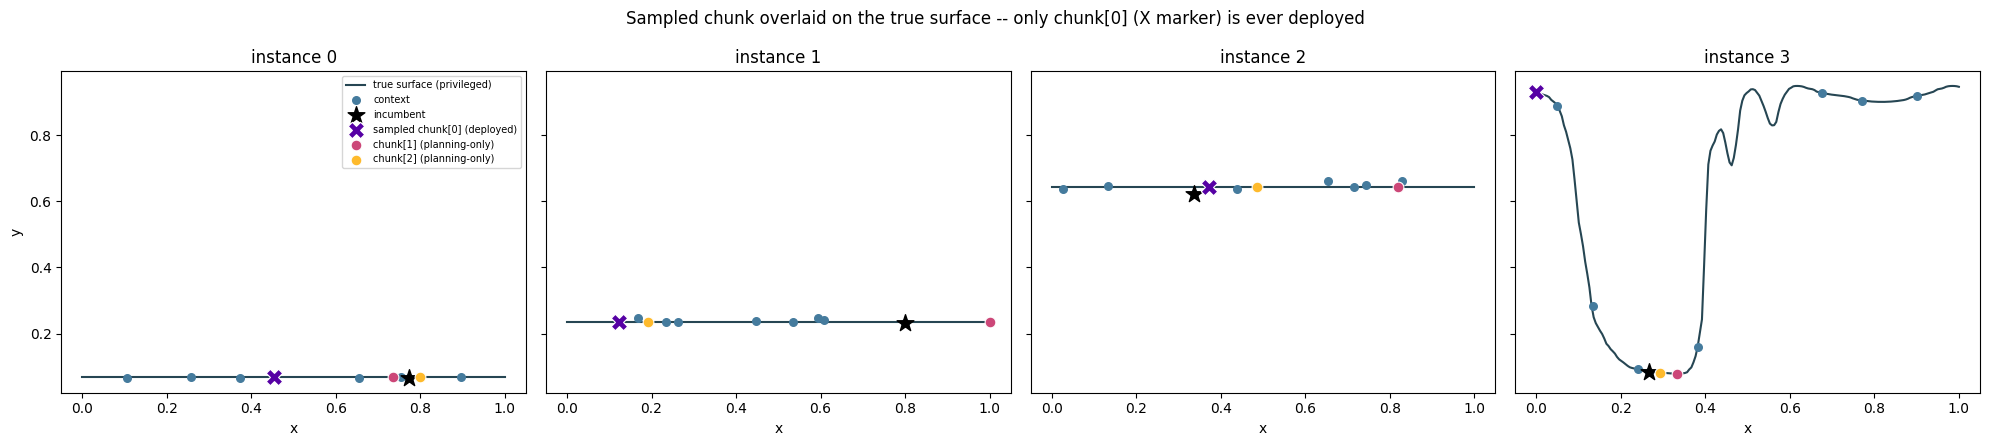

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
grid = torch.linspace(0.0, 1.0, 200).view(1, -1, 1).expand(4, -1, -1)
with torch.no_grad():
    true_y = eval_prior.evaluate(grid, noise=False)  # [4, 200]

final_chunk = traj[-1]  # [B, chunk_len, x_dim], already clamped to [0,1]
for b, ax in enumerate(axes):
    ax.plot(grid[b, :, 0].numpy(), true_y[b].numpy(), color="#264653", linewidth=1.5, label="true surface (privileged)")
    ax.scatter(x_ctx[b, :, 0].numpy(), y_ctx[b].numpy(), color="#457b9d", s=30, zorder=4, label="context")
    incumbent_idx = y_ctx[b].argmin()
    ax.scatter(x_ctx[b, incumbent_idx, 0].item(), y_ctx[b, incumbent_idx].item(), color="black", marker="*", s=160,
               zorder=5, label="incumbent")
    for c in range(chunk_len):
        x_c = final_chunk[b, c, 0].item()
        y_c = eval_prior.evaluate(torch.full((4, 1, 1), x_c), noise=False)[b, 0].item()
        marker = "X" if c == 0 else "o"
        size = 140 if c == 0 else 60
        ax.scatter(x_c, y_c, color=colors[c], marker=marker, s=size, edgecolor="white", linewidth=0.8, zorder=6,
                   label=(f"sampled chunk[0] (deployed)" if c == 0 else f"chunk[{c}] (planning-only)") if b == 0 else None)
    ax.set_xlabel("x")
    ax.set_title(f"instance {b}")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("Sampled chunk overlaid on the true surface -- only chunk[0] (X marker) is ever deployed")
fig.tight_layout()
plt.show()

## Interpretation

**Loss curve**: `policy_loss/train` drops from 1.42 at rollout 0 to a noisy plateau mostly in the 0.35-0.6 range by rollout 39 -- real, if noisy (per-rollout batch sizes and branch mixes vary quite a bit, e.g. `n_explore` swings from 14 to 108 across rollouts, so per-rollout loss noise is expected), learning signal, consistent with `docs/MILESTONES.md`'s own reported 20-rollout demo (3.96 -> 0.39) on the same architecture. This is a much shorter run than that demo and still shows the same qualitative drop.

**Denoising trajectory plot**: at `t=1` all three chunk-step tokens start scattered near 0 (their independent standard-normal draws), and by `t=0` they visibly separate into **distinct, non-collapsed positions** -- e.g. instance 0 ends with chunk[1] (pink) at ~0.74, chunk[2] (yellow) at ~0.80, and chunk[0] (purple) at ~0.45, not three copies of the same value. That's a real, non-trivial finding: the head is using its `chunk_len` planning capacity to represent genuinely different points per chunk step, not degenerating to a single repeated action (which was a real risk this architecture could have fallen into, given `chunk_pos_embed` is the only thing breaking the tokens' symmetry). Some trajectories also visibly leave `[0,1]` mid-integration (e.g. instance 2's chunk[1] briefly exceeds 1.0) -- expected and documented behavior, since `sample()` only clamps the final point, not every intermediate step.

**Surface overlay plot**: mixed, and worth reporting as mixed rather than rounding up. The deployed point (`chunk[0]`, purple X) lands close to the context's own incumbent for instances 0 and 2, but noticeably far from it for instance 1 (incumbent at x~0.8, sampled point at x~0.12) and for instance 3 lands near x=0, a comparatively high-y (worse) region of that instance's more complex, multimodal true surface. That spread is exactly what's expected from a head trained for only 40 rollouts on privileged-search labels whose own quality is still an open question (`docs/MILESTONES.md`'s bottleneck list) -- this notebook's job was to confirm the *mechanism* produces structured, non-degenerate, in-domain plans, not to claim the *policy* is good yet. Whether it becomes reliably good is exactly what `configs/experiment/action_head_flow_integrated_real.yaml` (800 rollouts, not 40) run against `auc_improvement_vs_random` -- and compared to the simple head's own result -- would actually answer, per the sequencing `docs/MILESTONES.md` lays out.